<a href="https://colab.research.google.com/github/Arka13/GoogleColabRepo/blob/main/20260927_week2_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Diagnosis: Polynomial Regression, Regularization & Logistic Regression

**Week 2 — Building on Week 1**

| Step | What we do | Why |
|---|---|---|
| **1. Preprocessing** | Re-run the Week 1 pipeline | Clean data to model |
| **2. Polynomial Regression** | `PolynomialFeatures` + `LinearRegression`, `Ridge`, `Lasso` | See overfitting, then fix it with L2 / L1 |
| **3. Logistic Regression** | `LogisticRegression` | Turn the linear score into a probability |
| **Take-home** | Four exercises | Practice |

---

## Setup: Imports & Loading the Data

Same dataset as Week 1. We also import everything we need upfront so it is easy to see which
library each tool comes from.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, RidgeCV,
    LogisticRegression
)

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

In [ ]:
DATA_PATH = "/content/dataset.csv"
df = pd.read_csv(DATA_PATH, index_col=0)
df = df.drop('id', axis=1)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 1: Preprocessing Pipeline (Week 1 Recap)

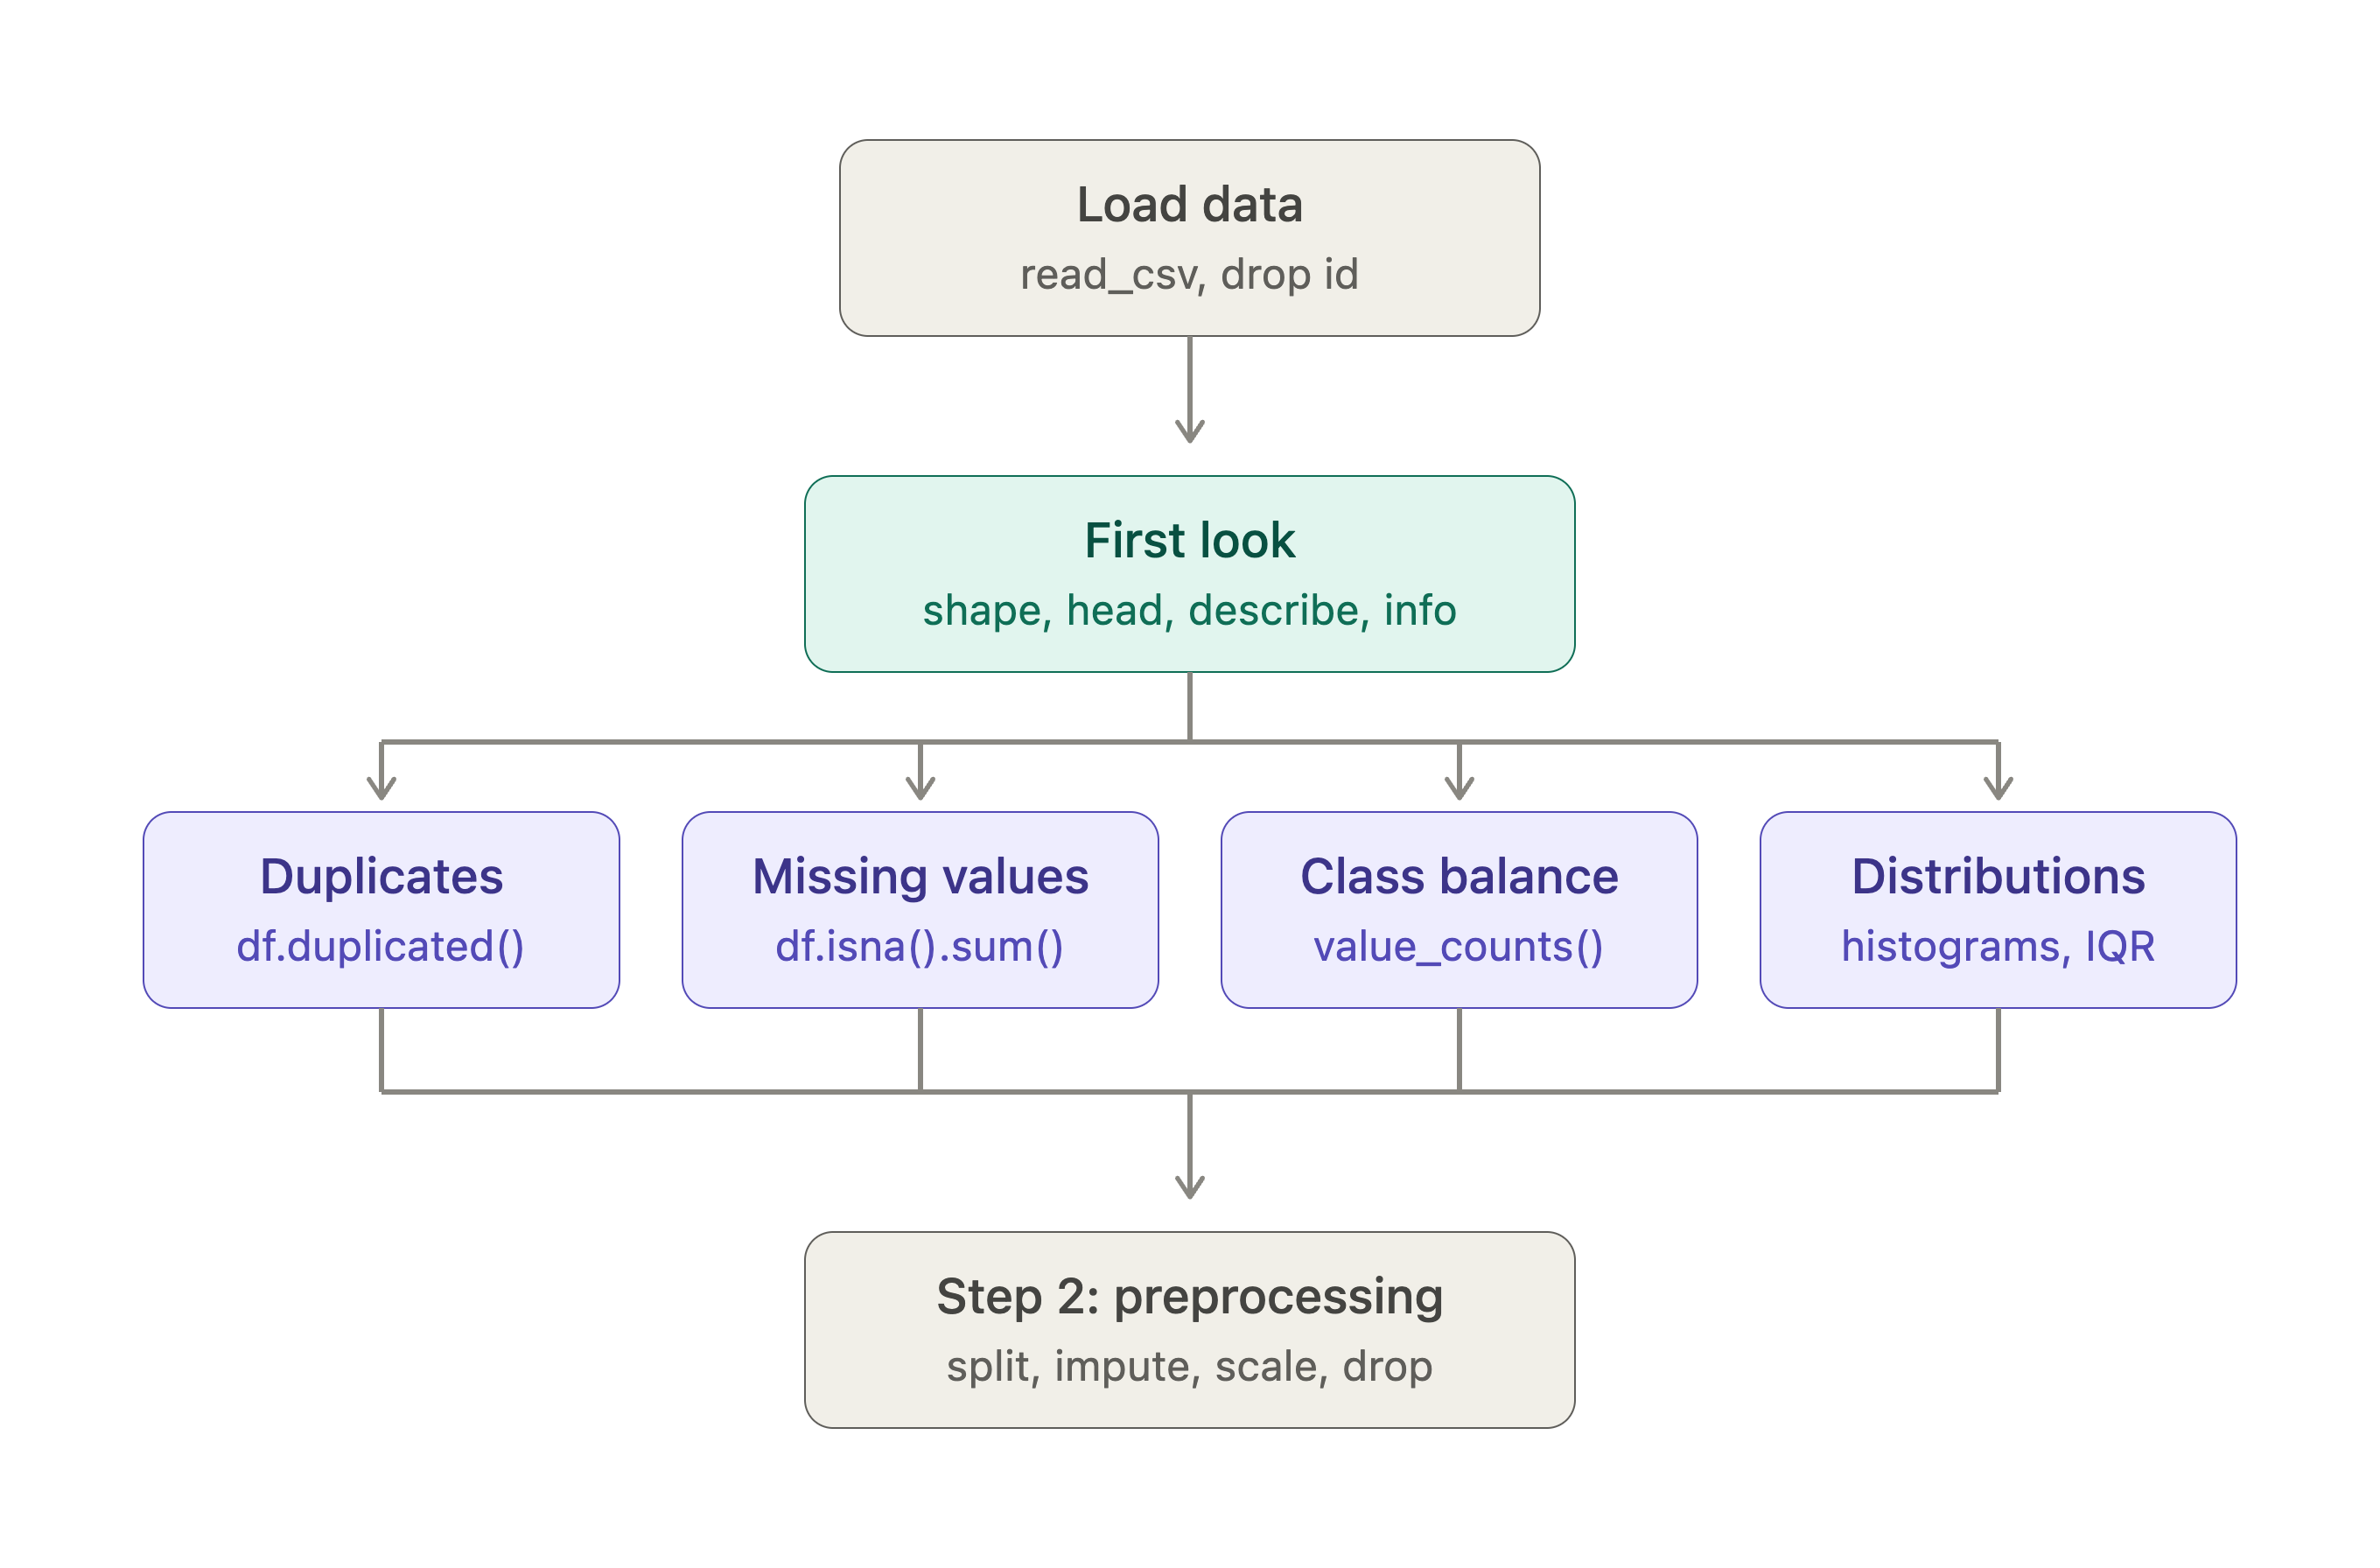

In [ ]:
# Labels: 1 = Malignant, 0 = Benign
X = df.drop('diagnosis', axis=1)
y = (df['diagnosis'] == 'M').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_cols = X.select_dtypes(include='number').columns

# Replace outliers
for col in numeric_cols: # Iterate through each numeric column

  Q1 = X_train[col].quantile(0.25) # Calculate the first quartile (25th percentile)
  Q3 = X_train[col].quantile(0.75) # Calculate the third quartile (75th percentile)
  IQR = Q3 - Q1 # Calculate the Interquartile Range (IQR)

  lower = Q1 - 1.5*IQR # Calculate the lower bound for outlier detection
  upper = Q3 + 1.5*IQR # Calculate the upper bound for outlier detection

  outlier_mask = (X_train[col] < lower) | (X_train[col] > upper) # Boolean mask: True where the value is an outlier
  num_outliers = outlier_mask.sum() # Count the number of outliers based on IQR

  if num_outliers > 0:
    median_val = X_train.loc[~outlier_mask, col].median() # Median computed from non-outlier values only
    X_train.loc[outlier_mask, col] = median_val # Replace each outlier with that column's median

    # apply the SAME train-fit bounds and value to test
    test_outlier_mask = (X_test[col] < lower) | (X_test[col] > upper)
    X_test.loc[test_outlier_mask, col] = median_val


# Scale
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# Drop highly correlated features (same threshold as Week 1: r > 0.9)
corr_matrix = X_train.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # each pair counted once
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]
X_train = X_train.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Dropped (high correlation): {to_drop}")

Training set : (455, 25)
Test set     : (114, 25)
Dropped (high correlation): ['perimeter_mean', 'area_mean', 'perimeter_se', 'radius_worst', 'perimeter_worst']


### Evaluation Helper

We will call this for every model variant, so let us define it once.

In [ ]:
results = {}   # we will fill this as we go

def evaluate(model_name, y_true, y_pred):

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)

    print(f"  {model_name}")
    print(f"  Accuracy  : {acc*100:.1f}%")
    print(f"  Precision : {prec:.3f}")
    print(f"  Recall    : {rec:.3f}")
    print(f"  F1 Score  : {f1:.3f}")

    cm   = confusion_matrix(y_true, y_pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Malignant', 'Benign'])
    disp.plot(colorbar=False)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()

    results[model_name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1
    }

---

## 2: Polynomial Regression

We fit **linear regression** to the 0/1 label and call scores ≥ 0.5 "Malignant".

1. **Polynomial features** add squares (x₁²) and interactions (x₁·x₂) so a linear model can bend.
2. **Overfitting**: high train accuracy, much lower test accuracy.
3. **Regularization**: a penalty on large weights that restrains the model.

### 2.1 Watching a model overfit

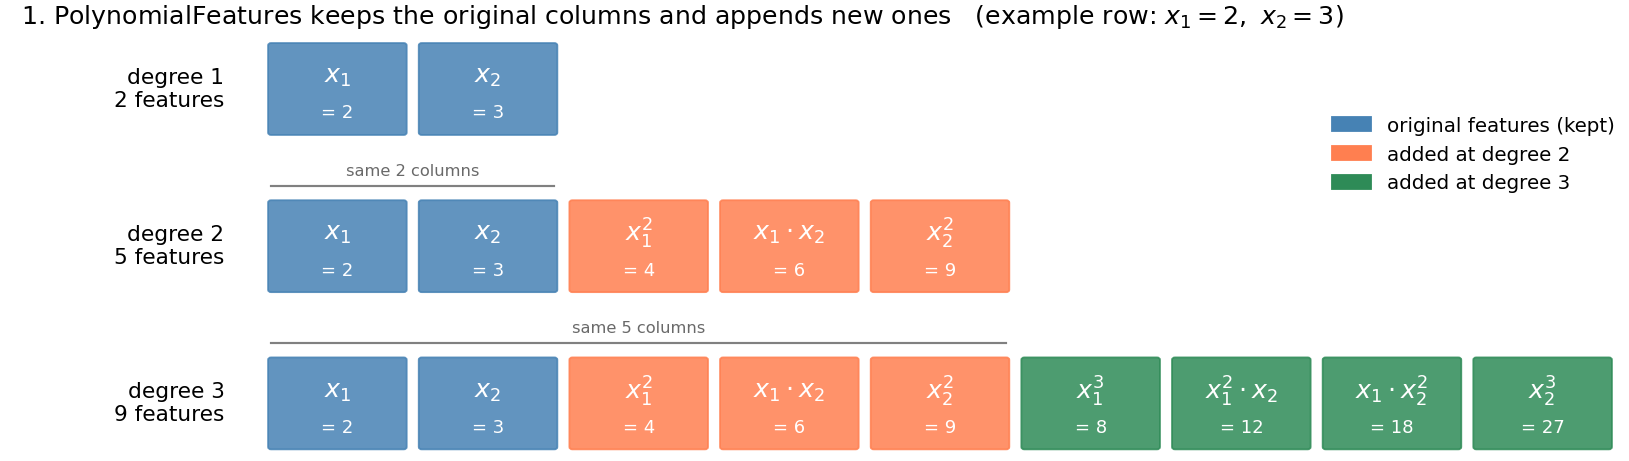

#### Decision Boundary Example

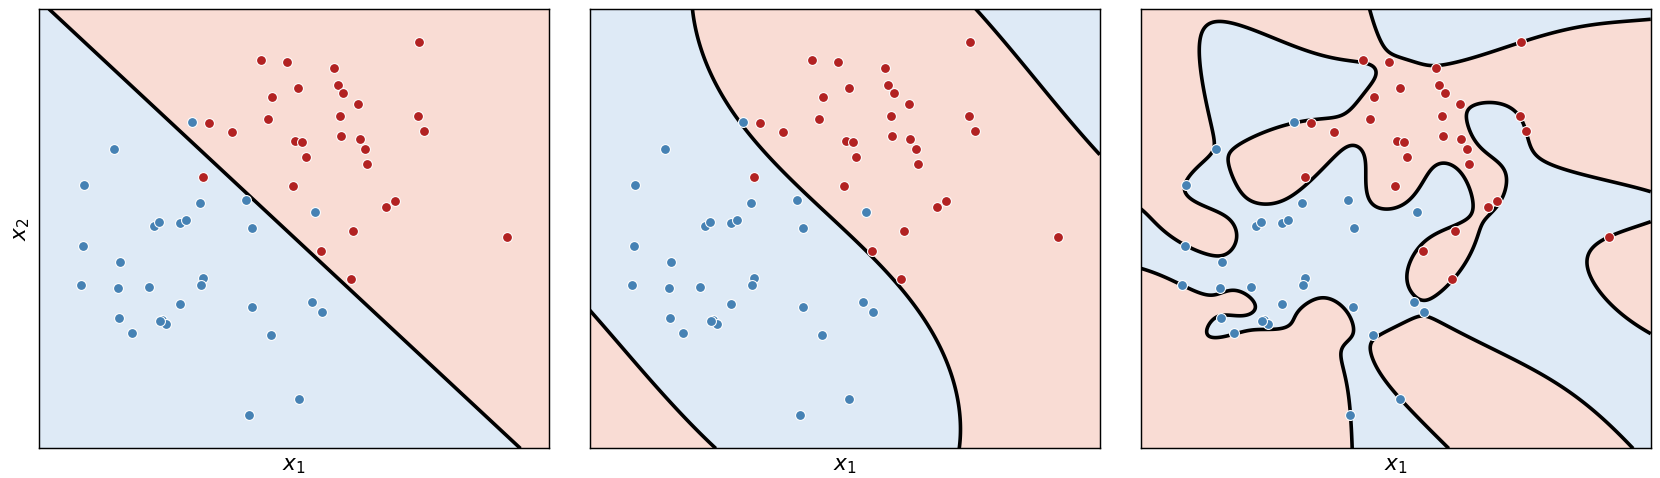

In [ ]:
degrees = [1, 2, 3]

train_accuracy_scores = []
test_accuracy_scores = []

print(f"{'Degree':>6} | {'# Features':>10} | {'Train Accuracy':>14} | {'Test Accuracy':>13}")
print("-" * 52)

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    poly_scaler = StandardScaler()
    X_train_poly = poly_scaler.fit_transform(X_train_poly)
    X_test_poly = poly_scaler.transform(X_test_poly)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Continuous predictions
    train_pred_scores = model.predict(X_train_poly)
    test_pred_scores = model.predict(X_test_poly)

    # Apply threshold
    train_pred = (train_pred_scores >= 0.5).astype(int)
    test_pred = (test_pred_scores >= 0.5).astype(int)

    train_accuracy = accuracy_score(y_train, train_pred)*100
    test_accuracy = accuracy_score(y_test, test_pred)*100

    train_accuracy_scores.append(train_accuracy)
    test_accuracy_scores.append(test_accuracy)

    print(
        f"{degree:>6} | {X_train_poly.shape[1]:>10} | "
        f"{train_accuracy:>13.1f}% | {test_accuracy:>12.1f}%"
    )

Degree | # Features | Train Accuracy | Test Accuracy
----------------------------------------------------
     1 |         25 |          95.8% |         98.2%
     2 |        350 |         100.0% |         74.6%
     3 |       3275 |         100.0% |         75.4%


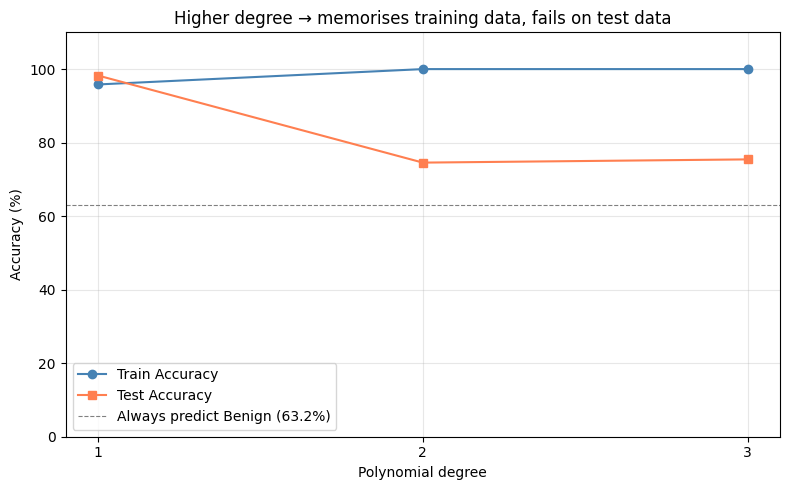

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_accuracy_scores, 'o-', color='steelblue', label='Train Accuracy')
plt.plot(degrees, test_accuracy_scores,  's-', color='coral',     label='Test Accuracy')
# Majority-class baseline: always predict the more common class
baseline = max(np.mean(y_test), 1 - np.mean(y_test)) * 100
plt.axhline(baseline, color='gray', linewidth=0.8, linestyle='--',
            label=f'Always predict Benign ({baseline:.1f}%)')
plt.ylim(0, 110)
plt.xticks(degrees)
plt.xlabel('Polynomial degree')
plt.ylabel('Accuracy (%)')
plt.title('Higher degree → memorises training data, fails on test data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Fixing overfitting with regularization (L1 & L2)

.

**Ridge regression** (L2 penalty):

$$
\min_{w,\,b} \;\; \underbrace{\lVert y - Xw - b \rVert_2^2}_{\text{sum of squared errors}} \;+\; \underbrace{\alpha \lVert w \rVert_2^2}_{\alpha \sum_j w_j^2}
$$


**Lasso regression** (L1 penalty):

$$
\min_{w,\,b} \;\; \underbrace{\frac{1}{2n} \lVert y - Xw - b \rVert_2^2}_{\text{mean squared error (scaled)}} \;+\; \underbrace{\alpha \lVert w \rVert_1}_{\alpha \sum_j |w_j|}
$$



| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty | sum of **squared** weights | sum of **absolute** weights |
| Regularization Strength | `alpha` (larger = stronger) | `alpha` (larger = stronger) |
| Effect | shrinks all weights | sets some to **exactly 0** |

Same degree-3 features, three models.


In [ ]:
# Build degree-3 features once and reuse them
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly3.fit_transform(X_train)
X_test_poly  = poly3.transform(X_test)

poly_scaler = StandardScaler()
X_train_poly = poly_scaler.fit_transform(X_train_poly)
X_test_poly = poly_scaler.transform(X_test_poly)

print(f"Degree-3 features: {X_train_poly.shape[1]}")

# Three models on the SAME features
lin_model   = LinearRegression().fit(X_train_poly, y_train)
ridge_model = Ridge(alpha=1e+04).fit(X_train_poly, y_train)
lasso_model = Lasso(alpha=0.023, max_iter=200).fit(X_train_poly, y_train)

print(f"\n{'Model':<22} | {'Train Accuracy':>14} | {'Test Accuracy':>13}")
print("-" * 55)

for name, model in [
    ('Linear (no penalty)', lin_model),
    ('Ridge (L2)', ridge_model),
    ('Lasso (L1)', lasso_model)
]:

    # Continuous predictions
    train_pred = model.predict(X_train_poly)
    test_pred  = model.predict(X_test_poly)

    # Convert to classes using threshold 0.5
    train_pred = (train_pred >= 0.5).astype(int)
    test_pred  = (test_pred >= 0.5).astype(int)

    tr = accuracy_score(y_train, train_pred)*100
    te = accuracy_score(y_test, test_pred)*100

    print(f"{name:<22} | {tr:>13.1f}% | {te:>12.1f}%")

Degree-3 features: 3275

Model                  | Train Accuracy | Test Accuracy
-------------------------------------------------------
Linear (no penalty)    |         100.0% |         75.4%
Ridge (L2)             |          90.5% |         90.4%
Lasso (L1)             |          96.9% |         96.5%




### 2.3 How many weights did Lasso switch off?

Lasso's zero weights amount to automatic **feature selection**; Ridge keeps every weight.

Total features: 3275

Linear (no penalty)    zero weights:    0   (active: 3275)
Ridge (L2)             zero weights:    0   (active: 3275)
Lasso (L1)             zero weights: 3235   (active: 40)


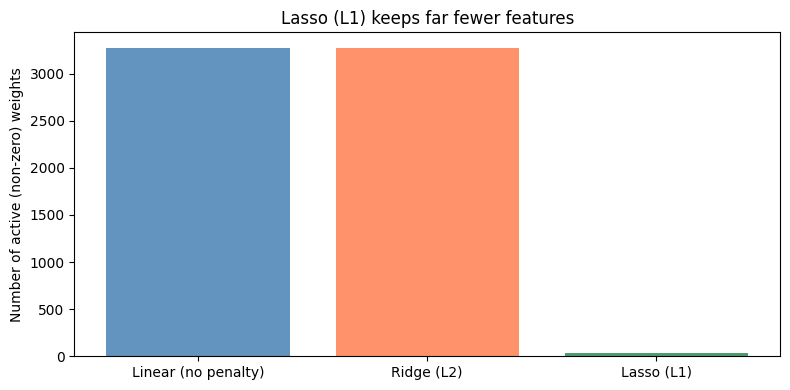

In [ ]:
# Count how many coefficients are exactly zero in each model
n_features = X_train_poly.shape[1]
counts = {
    'Linear (no penalty)': int(np.sum(lin_model.coef_   == 0)),
    'Ridge (L2)':          int(np.sum(ridge_model.coef_ == 0)),
    'Lasso (L1)':          int(np.sum(lasso_model.coef_ == 0)),
}

print(f"Total features: {n_features}\n")
for name, zeros in counts.items():
    print(f"{name:<22} zero weights: {zeros:>4}   (active: {n_features - zeros})")

# Picture 1: how many weights stay ACTIVE (non-zero) in each model
plt.figure(figsize=(8, 4))
active = [n_features - z for z in counts.values()]
plt.bar(list(counts.keys()), active, color=['steelblue', 'coral', 'seagreen'], alpha=0.85)
plt.ylabel('Number of active (non-zero) weights')
plt.title('Lasso (L1) keeps far fewer features')
plt.tight_layout()
plt.show()

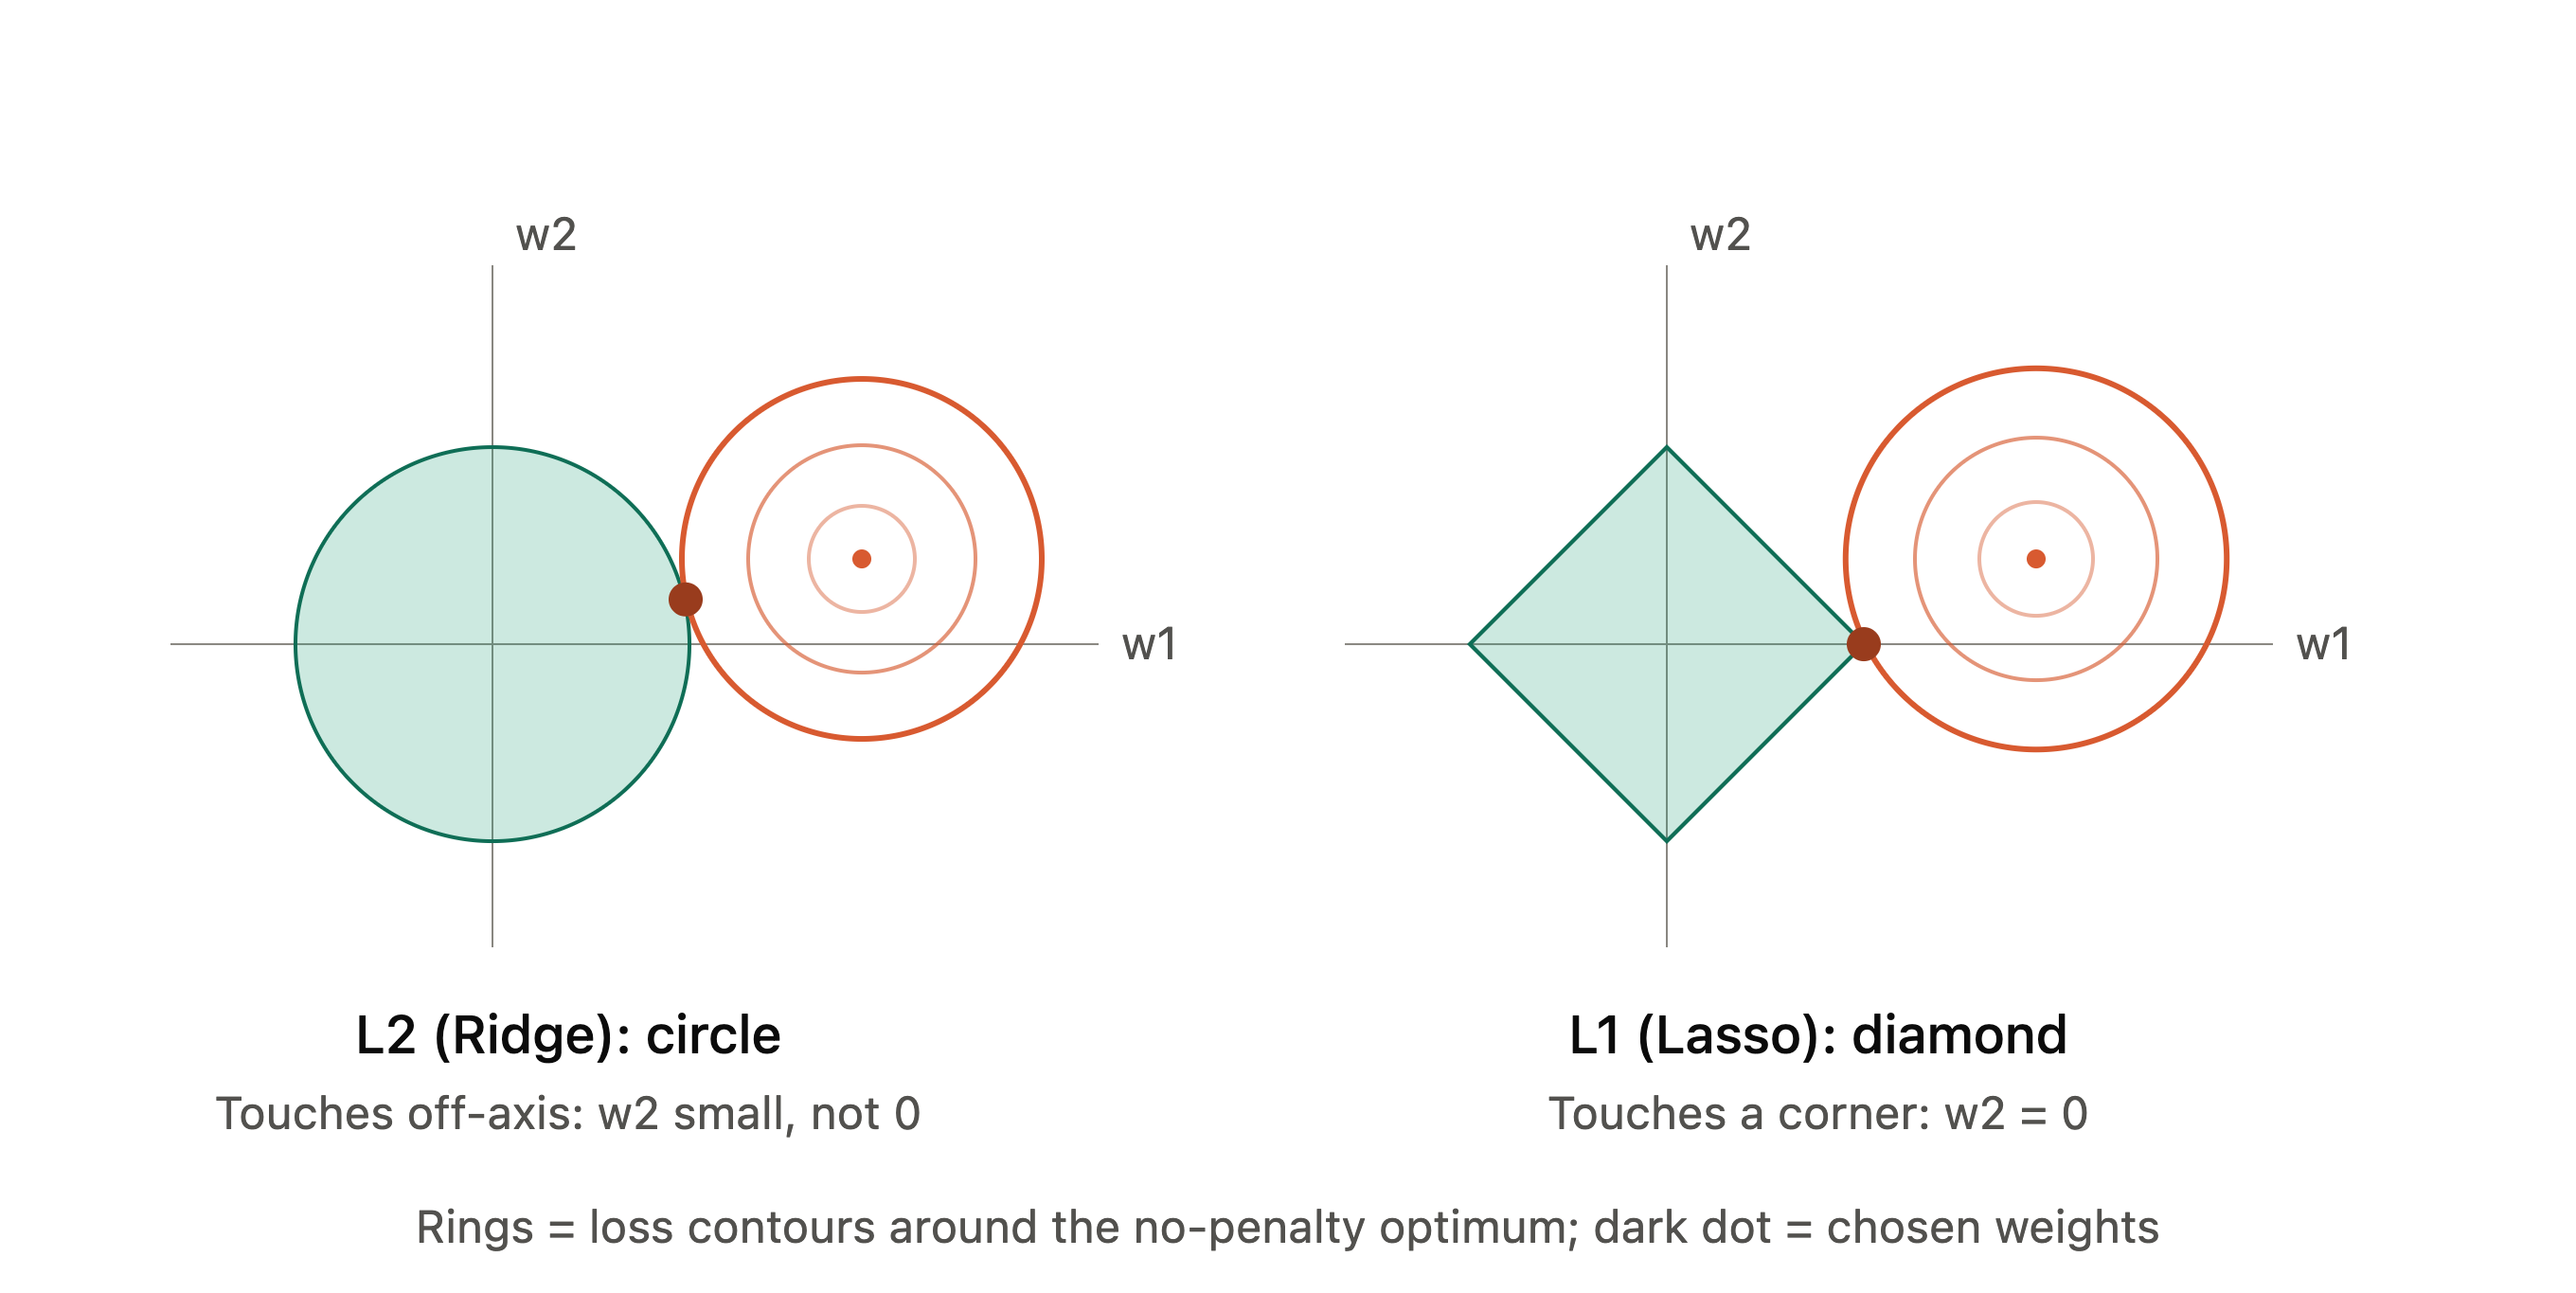

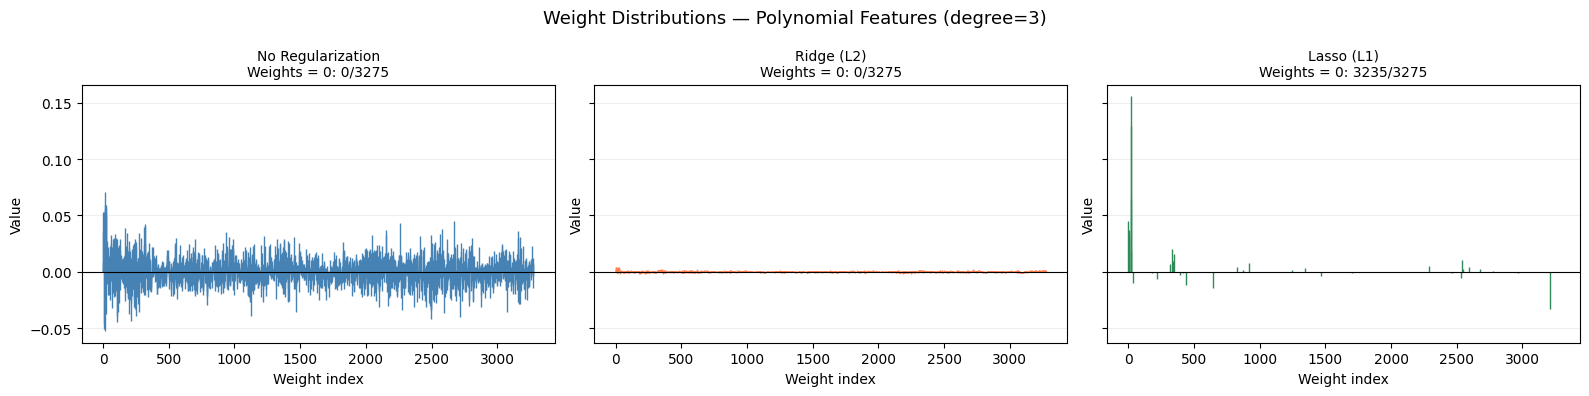

No reg : std = 0.0116
Ridge  : std = 0.0006  (shrunk, but none exactly 0)
Lasso  : std = 0.0040  (many exactly 0 -> sparse model)
Lasso  : 3235 of 3275 weights zeroed out


In [ ]:
w_noreg = lin_model.coef_
w_ridge = ridge_model.coef_
w_lasso = lasso_model.coef_

# Shared y-axis (no fixed limits) so the three panels are directly comparable and nothing is clipped
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, w, title, color in zip(
    axes,
    [w_noreg, w_ridge, w_lasso],
    ['No Regularization', 'Ridge (L2)', 'Lasso (L1)'],
    ['steelblue', 'coral', 'seagreen']
):
    # vlines draws every weight at least 1 pixel wide (3275 thin bars can vanish when rendered)
    ax.vlines(range(len(w)), 0, w, color=color, linewidth=1)
    ax.axhline(0, color='k', linewidth=0.8)
    zero_count = (np.abs(w) == 0).sum()
    ax.set_title(f'{title}\nWeights = 0: {zero_count}/{len(w)}', fontsize=10)
    ax.set_xlabel('Weight index'); ax.set_ylabel('Value')
    ax.grid(True, alpha=0.2, axis='y')
plt.suptitle('Weight Distributions — Polynomial Features (degree=3)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"No reg : std = {w_noreg.std():.4f}")
print(f"Ridge  : std = {w_ridge.std():.4f}  (shrunk, but none exactly 0)")
print(f"Lasso  : std = {w_lasso.std():.4f}  (many exactly 0 -> sparse model)")
print(f"Lasso  : {(np.abs(w_lasso) == 0).sum()} of {len(w_lasso)} weights zeroed out")

---

## 3: Logistic Regression

Pass the linear score through a **sigmoid** so the output is a probability in (0, 1):

$$P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}, \qquad z = w_0 + w_1 x_1 + \cdots + w_n x_n$$

scikit-learn minimises the log-loss **plus an L2 penalty** by default:



$$
= \frac{1}{2C}\lVert w \rVert_2^2 \;+\; \sum_{i=1}^{N} -\Big[y^{(i)}\log \hat{p}^{(i)} + (1 - y^{(i)})\log(1 - \hat{p}^{(i)})\Big]
$$


`C = 1.0` by default; **smaller `C` = stronger penalty** (the opposite of `alpha`).
There is no closed-form solution, so the default solver `lbfgs` (a faster relative of gradient descent) finds the weights iteratively.

Train accuracy: 97.1%

  Logistic Regression
  Accuracy  : 98.2%
  Precision : 1.000
  Recall    : 0.952
  F1 Score  : 0.976


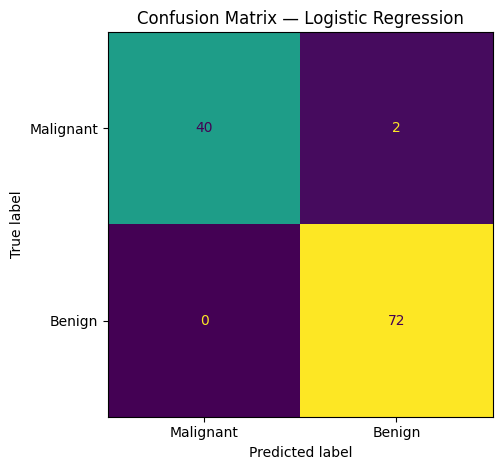

In [ ]:
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print(f"Train accuracy: {lr_model.score(X_train, y_train)*100:.1f}%\n")

evaluate('Logistic Regression', y_test, y_pred_lr)

## Summary

| Model | Train | Test |
|---|---|---|
| Linear, degree 1 | 95.8% | **98.2%** |
| Linear, degree 3 | 100.0% | 75.4% |
| Ridge, degree 3 (`alpha=1e4`) | 90.5% | 90.4% |
| Lasso, degree 3 (40 active weights) | 96.9% | 96.5% |
| Logistic regression | 97.1% | **98.2%** |



---

## Take-home Exercise 1 — Why didn't polynomial regression help?

Explain why degree 2 and 3 did not beat degree 1 on the test set. Then find a dataset where
polynomial regression *does* win.

*Difficulty: Moderate*

*Your answer:*

---

## Take-home Exercise 2 — Polynomial Logistic Regression

Feed degree-2 polynomial features into `LogisticRegression`, fill in the `____` blanks, and compare with Step 3.

*Hint: compare C = 1, 0.1, 0.01 and explain what you see. Optional: add a `StandardScaler` after the
polynomial step, as in 2.1–2.2.*

*Difficulty: High*

In [ ]:
# fill in the blanks (____) and run, using the breast-cancer data

# Step 1: build degree-2 polynomial features from the training and test sets
poly = PolynomialFeatures(degree=____, include_bias=False)
X_train_poly = poly.____(X_train)
X_test_poly  = poly.____(X_test)
print("Number of features:", X_train_poly.shape[1])

# Step 2: train logistic regression on the polynomial features
poly_logreg = LogisticRegression(max_iter=5000, C=____)
poly_logreg.fit(____, ____)

# Step 3: evaluate with the SAME helper we used everywhere else
y_pred_poly = poly_logreg.predict(____)
evaluate('Polynomial Logistic Regression', y_test, y_pred_poly)

---

## Take-home Exercise 3 — Choose `alpha` with cross-validation

In 2.2, Ridge's `alpha=1e4` was fixed by hand and underfit (90.4% test). Let cross-validation pick it instead,
using only the training data. Fill in the pipeline below, fit it, and compare its test accuracy with 2.2.

*Hint: `RidgeCV` tries every value in `alphas` and keeps the one with the best validation score. Use degree 3
so the comparison with 2.2 is fair.*

*Difficulty: Moderate*

In [ ]:
alphas = np.logspace(-3, 5, 20)   # 0.001 to 100,000

ridge_cv = make_pipeline(
    PolynomialFeatures(degree=____, include_bias=False),
    StandardScaler(),
    RidgeCV(alphas=____)
)
ridge_cv.fit(____, ____)

print("Best alpha:", ridge_cv[-1].alpha_)
test_pred = (ridge_cv.predict(____) >= 0.5).astype(int)
print(f"Test accuracy: {accuracy_score(y_test, test_pred)*100:.1f}%")

---

## Take-home Exercise 4 — Moving the decision threshold

`predict()` calls a tumour malignant when its probability is ≥ 0.5. In screening, missing a
malignant tumour is far worse than a false alarm. Lower the threshold and watch the trade-off.

1. How many malignant tumours are missed at each threshold? How many false alarms appear?
2. Which threshold would you choose for screening, and why?
3. Why does lowering the threshold from 0.5 to 0.2 not rescue the missed tumours?

*Difficulty: Moderate*

In [ ]:
probs = lr_model.predict_proba(____)[:, 1]   # probability of Malignant

print(f"{'Threshold':>9} | {'Recall':>6} | {'Precision':>9} | {'Missed':>6} | {'False alarms':>12}")
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred_t = (probs >= ____).astype(int)
    missed       = ((y_pred_t == 0) & (y_test == 1)).sum()
    false_alarms = ((y_pred_t == 1) & (y_test == 0)).sum()
    print(f"{t:>9} | {recall_score(y_test, y_pred_t):>6.3f} | "
          f"{precision_score(y_test, y_pred_t):>9.3f} | {missed:>6} | {false_alarms:>12}")